In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [35]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [36]:
print(df.isnull().sum())
df.columns = df.columns.str.strip()
df = df.dropna()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.info()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 740 entries, 0 to 753
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labou

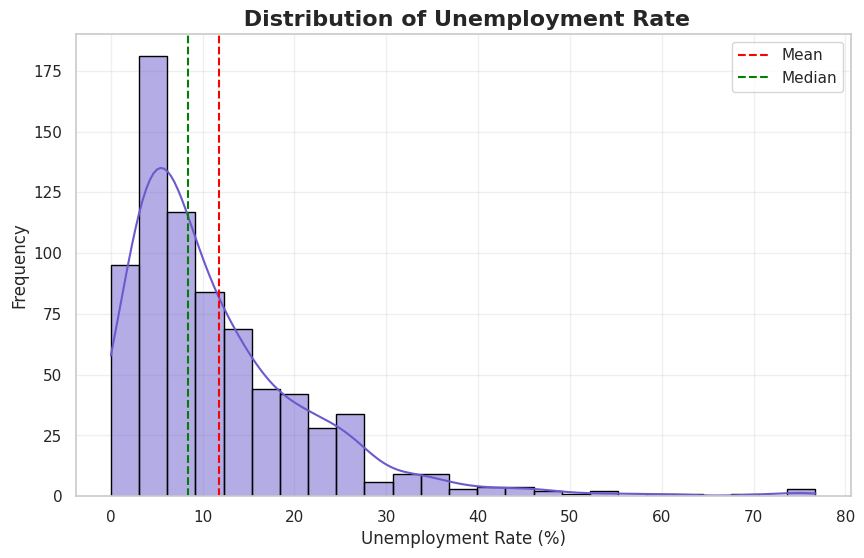

In [37]:
plt.figure(figsize=(10,6))
sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=25,
    kde=True,
    color='#6A5ACD',
    edgecolor='black'
)
plt.axvline(df['Estimated Unemployment Rate (%)'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Estimated Unemployment Rate (%)'].median(), color='green', linestyle='--', label='Median')
plt.title(" Distribution of Unemployment Rate", fontsize=16, fontweight='bold')
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

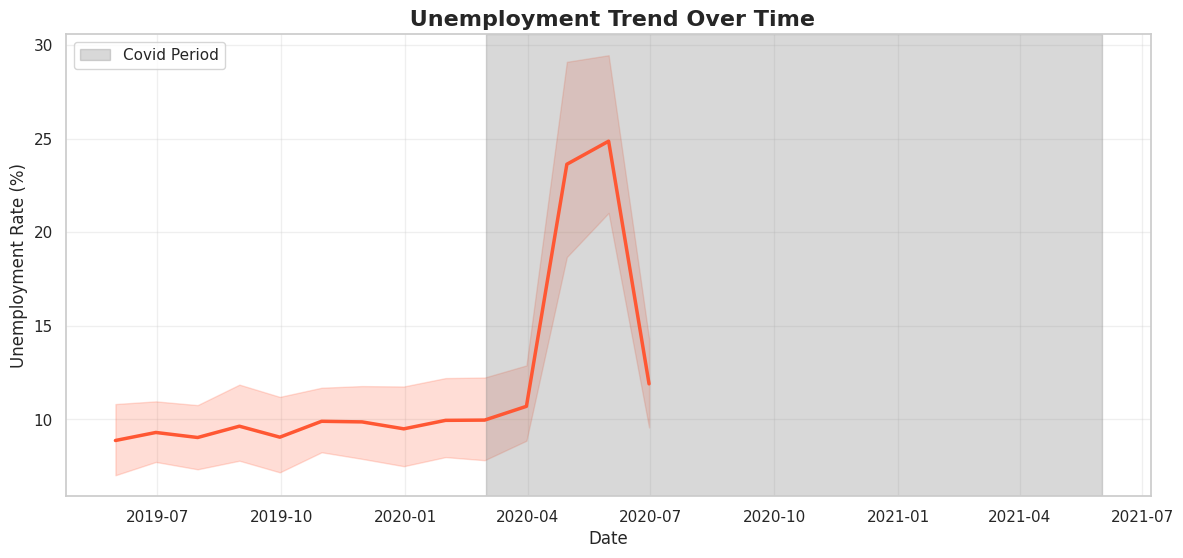

In [38]:
plt.figure(figsize=(14,6))
sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=df,
    color='#FF5733',
    linewidth=2.5
)
plt.axvspan(pd.to_datetime('2020-03-01'), pd.to_datetime('2021-06-01'),
            color='gray', alpha=0.3, label='Covid Period')
plt.title(" Unemployment Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

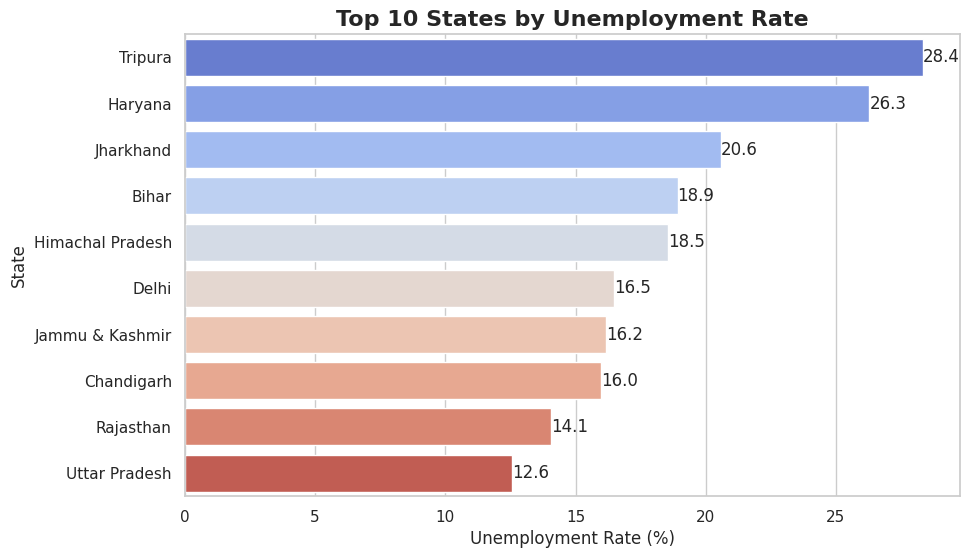

In [39]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
top_states = state_avg.sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_states.values,
    y=top_states.index,
    hue=top_states.index, # Explicitly assign y to hue
    palette='coolwarm',
    legend=False # Suppress redundant legend
)
plt.title("Top 10 States by Unemployment Rate", fontsize=16, fontweight='bold')
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State")
for i, v in enumerate(top_states.values):
    plt.text(v, i, f"{v:.1f}", va='center')
plt.show()

/tmp/ipykernel_14959/617717053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


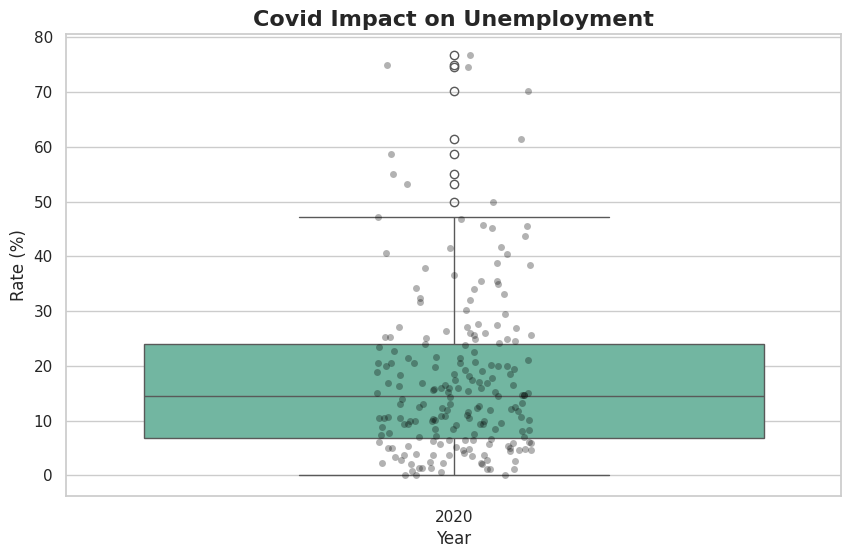

In [40]:
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Year',
    y='Estimated Unemployment Rate (%)',
    data=covid_data,
    palette='Set2'
)
sns.stripplot(
    x='Year',
    y='Estimated Unemployment Rate (%)',
    data=covid_data,
    color='black',
    alpha=0.3
)
plt.title("Covid Impact on Unemployment", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Rate (%)")
plt.show()

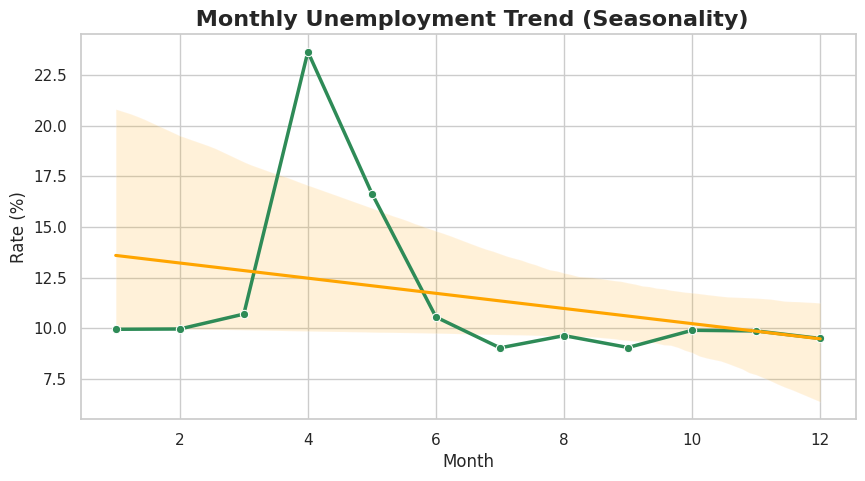

In [41]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()
plt.figure(figsize=(10,5))
sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker='o',
    color='#2E8B57',
    linewidth=2.5
)
sns.regplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    scatter=False,
    color='orange'
)
plt.title(" Monthly Unemployment Trend (Seasonality)", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Rate (%)")
plt.show()

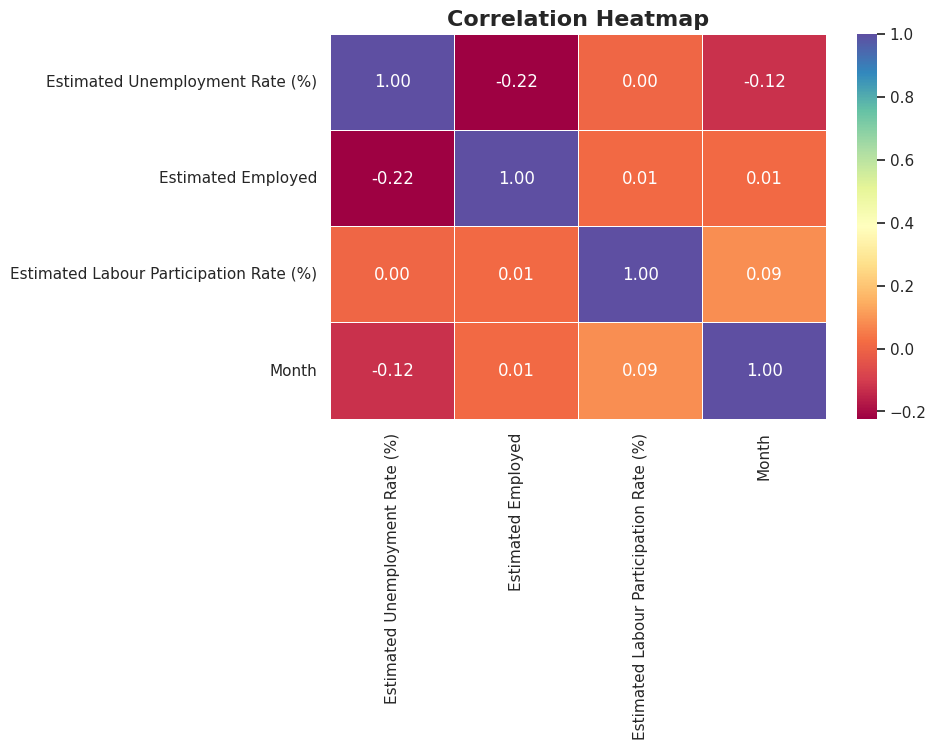

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='Spectral',
    linewidths=0.5,
    fmt='.2f'
)
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.show()

In [ ]:
print(" Average Unemployment Rate:", df['Estimated Unemployment Rate (%)'].mean())
print("\n State with Highest Unemployment:")
print(state_avg.tail(1))
print("\n State with Lowest Unemployment:")
print(state_avg.head(1))

 Average Unemployment Rate: 11.787945945945946

 State with Highest Unemployment:
Region
West Bengal    8.124643
Name: Estimated Unemployment Rate (%), dtype: float64

 State with Lowest Unemployment:
Region
Andhra Pradesh    7.477143
Name: Estimated Unemployment Rate (%), dtype: float64


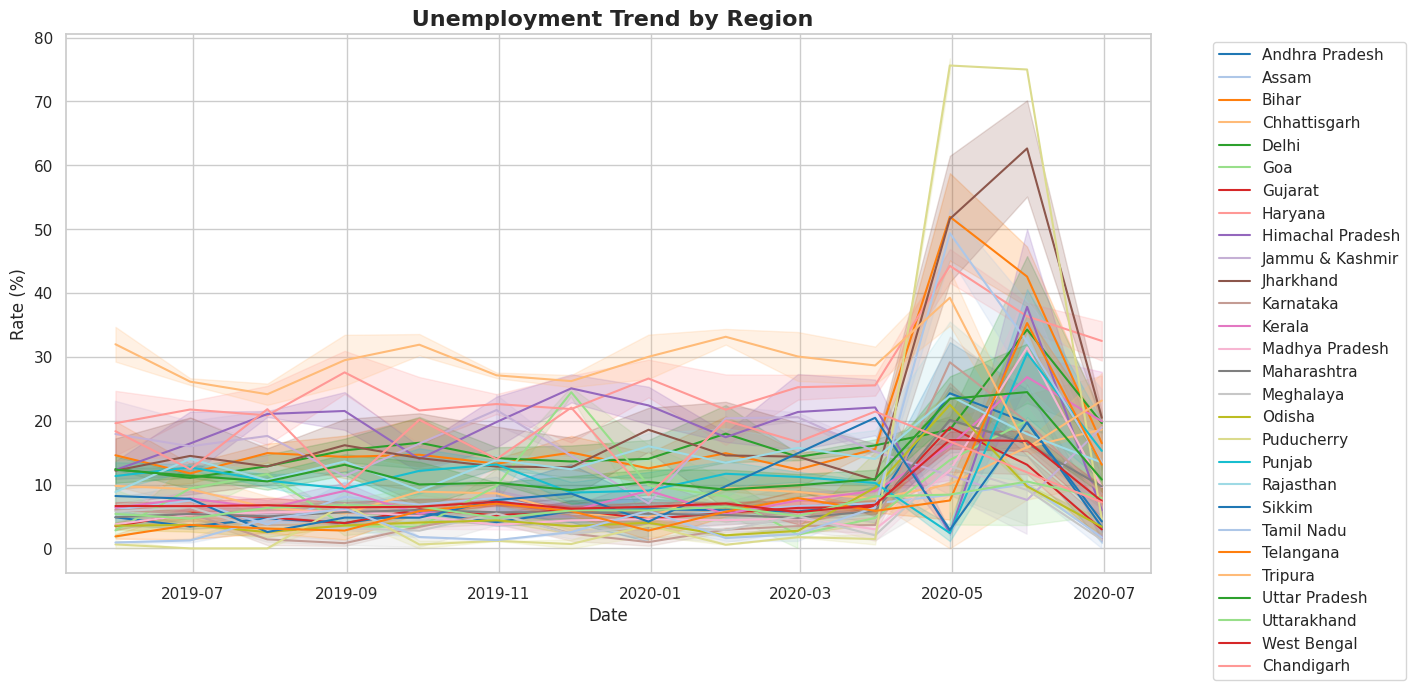

In [ ]:
plt.figure(figsize=(14,7))
sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region',
    data=df,
    palette='tab20',
    linewidth=1.5
)
plt.title(" Unemployment Trend by Region", fontsize=16, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()